In [2]:
%matplotlib widget
import ipywidgets as widgets
import csv
import time
import numpy as np
import matplotlib.pyplot as plt

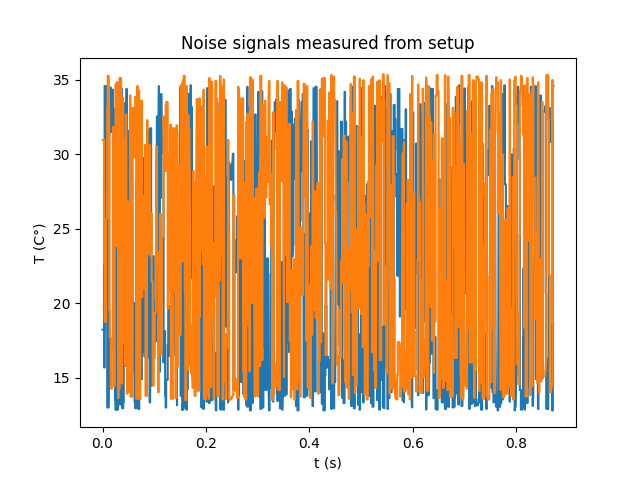

In [16]:
total_data = np.genfromtxt('ExperimentData_NoiseSignal.csv', delimiter=',')[1:,0:]
plt.close()
temperature_signal1 = total_data[:,1]
temperature_signal2 = total_data[:,2]
plt.plot(total_data[:,0], np.transpose([temperature_signal1, temperature_signal2]))
plt.xlabel('t (s)')
plt.ylabel('T (C°)')
plt.title('Noise signals measured from setup')
plt.show()


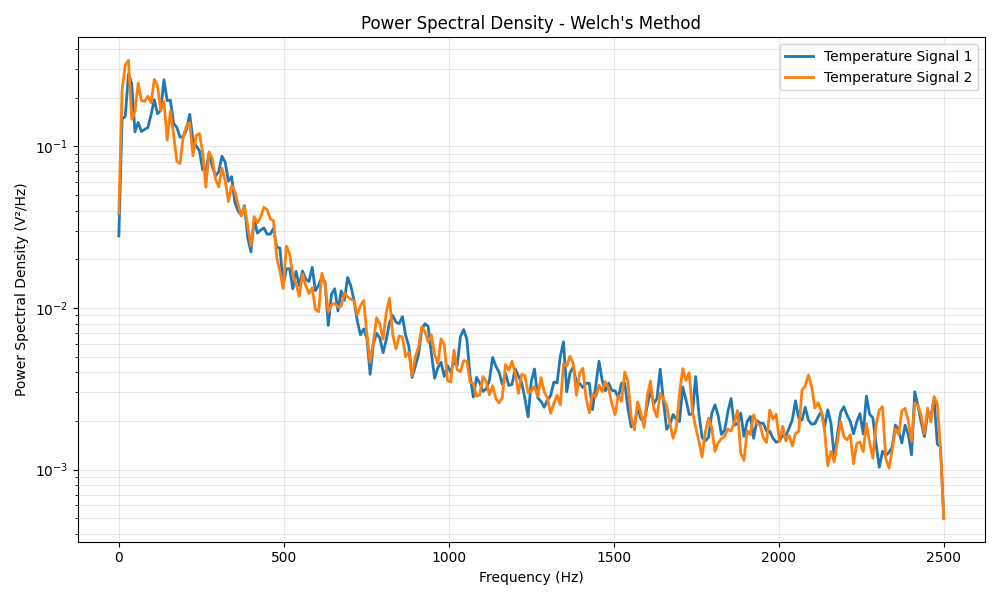

Sampling frequency: 5000.00 Hz
Frequency resolution: 9.7656 Hz


In [22]:
from scipy import signal
# Demean the signals
t_sig_demean1 = temperature_signal1 - np.mean(temperature_signal1)
t_sig_demean2 = temperature_signal2 - np.mean(temperature_signal2)

# Compute sampling rate (estimate from time vector)
time_vector = total_data[:, 0]
fs = 5000  # sampling frequency

# Compute PSD using Welch's method
frequencies1, psd1 = signal.welch(t_sig_demean1, fs=fs, nperseg=512)
frequencies2, psd2 = signal.welch(t_sig_demean2, fs=fs, nperseg=512)

# Plot the power spectral densities
plt.figure(figsize=(10, 6))
plt.semilogy(frequencies1, psd1, label='Temperature Signal 1', linewidth=2)
plt.semilogy(frequencies2, psd2, label='Temperature Signal 2', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V²/Hz)')
plt.title("Power Spectral Density - Welch's Method")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sampling frequency: {fs:.2f} Hz")
print(f"Frequency resolution: {frequencies1[1] - frequencies1[0]:.4f} Hz")

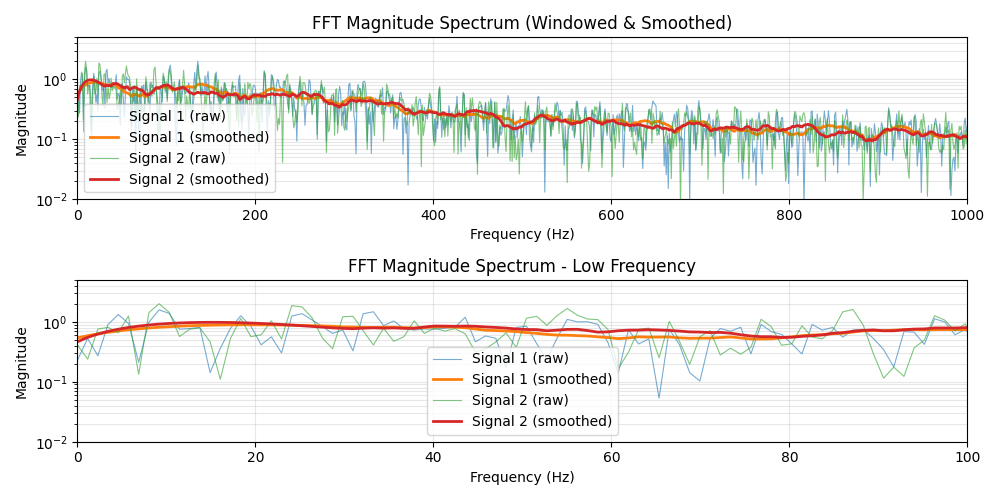

Window applied: Hann window
Smoothing applied: Savitzky-Goyal filter (window=51, polyorder=3)
Frequency range: 0 to 2498.28 Hz


In [31]:
# Apply Hann window to reduce spectral leakage
n = len(temperature_signal1)
window = np.hanning(n)
windowed_signal1 = t_sig_demean1 * window
windowed_signal2 = t_sig_demean2 * window

# Compute FFT of the windowed signals
fft1 = np.fft.fft(windowed_signal1)
fft2 = np.fft.fft(windowed_signal2)

# Get the frequency axis for FFT
freq_fft = np.fft.fftfreq(n, 1/fs)[:n//2]

# Compute magnitude spectrum (one-sided), normalized by window sum
window_sum = np.sum(window)
magnitude1 = 2.0/window_sum * np.abs(fft1[:n//2])
magnitude2 = 2.0/window_sum * np.abs(fft2[:n//2])

# Apply smoothing using Savitzky-Golay filter
from scipy.signal import savgol_filter
window_length = 51  # Must be odd
polyorder = 3
magnitude1_smooth = savgol_filter(magnitude1, window_length, polyorder)
magnitude2_smooth = savgol_filter(magnitude2, window_length, polyorder)

# Plot the FFT magnitude spectrum (raw and smoothed)
plt.figure(figsize=(10, 5))

# Full spectrum
plt.subplot(2, 1, 1)
plt.semilogy(freq_fft, magnitude1, label='Signal 1 (raw)', linewidth=0.8, alpha=0.6)
plt.semilogy(freq_fft, magnitude1_smooth, label='Signal 1 (smoothed)', linewidth=2)
plt.semilogy(freq_fft, magnitude2, label='Signal 2 (raw)', linewidth=0.8, alpha=0.6)
plt.semilogy(freq_fft, magnitude2_smooth, label='Signal 2 (smoothed)', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT Magnitude Spectrum (Windowed & Smoothed)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.xlim([0, 1000])
plt.ylim([1e-2, 5])

# Low frequency zoom
plt.subplot(2, 1, 2)
plt.semilogy(freq_fft, magnitude1, label='Signal 1 (raw)', linewidth=0.8, alpha=0.6)
plt.semilogy(freq_fft, magnitude1_smooth, label='Signal 1 (smoothed)', linewidth=2)
plt.semilogy(freq_fft, magnitude2, label='Signal 2 (raw)', linewidth=0.8, alpha=0.6)
plt.semilogy(freq_fft, magnitude2_smooth, label='Signal 2 (smoothed)', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT Magnitude Spectrum - Low Frequency')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.xlim([0, 100])
plt.ylim([1e-2, 5])
plt.tight_layout()
plt.show()

print(f"Window applied: Hann window")
print(f"Smoothing applied: Savitzky-Goyal filter (window={window_length}, polyorder={polyorder})")
print(f"Frequency range: 0 to {freq_fft[-1]:.2f} Hz")